In [1]:
# Import necessary packages 
import warnings
import sys 
if not sys.warnoptions:
    warnings.simplefilter("ignore")
import os
import numpy as np
import matplotlib, matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import scipy.io
import scipy.spatial.distance
import scipy.stats as stats
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
from glob import glob
import re 
import statsmodels.stats.multicomp as mc
import random
import pickle
import pdb
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ttest_1samp, sem, t
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import itertools
from functools import reduce
from scipy.io import loadmat

random.seed(3)

# Importing iPython tools
from IPython.display import display, HTML, Markdown, clear_output

pd.set_option('display.max_rows', 10)
%autosave 10

Autosaving every 10 seconds


**fMRI scan behavioral analyses**

*data processing*

In [2]:
base_dir      = './all_behav_data'
runs          = range(1, 10)
conds_prefix = {
    'Visual':      '/Visual/',
    'Audio':       '/Audio/',
    'Congruent':   '/Congruent/',
    'Incongruent': '/Incongruent/'
}

summary_list = []

for i in range(1, 33):
    subject = f"mm{str(i).zfill(2)}"
    mat_folder = os.path.join(base_dir, subject)
    if not os.path.isdir(mat_folder):
        print(f"Skipping missing folder for subject {subject}")
        continue

    subj_results = []

    for run in runs:
        fname = f'events_run_{run}_sub_{subject}.mat'
        fpath = os.path.join(mat_folder, fname)
        if not os.path.exists(fpath):
            continue

        mat = loadmat(fpath, struct_as_record=False, squeeze_me=True)
        data = mat.get('data')
        if data is None:
            continue

        # grab respTimes and trialTypes
        resp_times = np.array(data.respTime, dtype=np.float64).flatten()   # length 40
        trial_types = [str(t) for t in np.atleast_1d(data.trialType)]      # length 80
        trial_types = [trial_types[j] for j in range(len(trial_types)) if j % 2 == 0]    # length 40

        # filter to four conditions
        mask = [any(t.startswith(p) for p in conds_prefix.values()) for t in trial_types]
        rt40 = resp_times[mask]
        types40 = np.array(trial_types)[mask]

        # compute per‐condition metrics
        for cond_name, prefix in conds_prefix.items():
            sel = np.array([t.startswith(prefix) for t in types40])
            n_trials = sel.sum()
            if n_trials == 0:
                continue
            resp_sel = rt40[sel]
            accuracy = np.count_nonzero(~np.isnan(resp_sel)) / n_trials
            rt_valid = resp_sel[~np.isnan(resp_sel)] - 6
            mean_rt = float(np.mean(rt_valid)) if rt_valid.size>0 else np.nan

            subj_results.append({
                'cond': cond_name,
                'accuracy': accuracy,
                'mean_rt': mean_rt
            })

    if subj_results:
        subj_df = pd.DataFrame(subj_results)
        subj_summary = subj_df.groupby('cond').agg(
            overall_acc=('accuracy','mean'),
            overall_rt =('mean_rt','mean')
        ).reset_index()
        subj_summary['subject'] = subject
        summary_list.append(subj_summary)
        
summary_list = [df for df in summary_list if df['subject'].iloc[0] not in ['mm04', 'mm12']]

all_subjects_summary = pd.concat(summary_list, ignore_index=True)

cond_summary = (
    all_subjects_summary
    .groupby('cond')
    .agg(
        avg_accuracy = ('overall_acc','mean'),
        avg_rt       = ('overall_rt','mean')
    )
    .reset_index()
)

print(cond_summary)

          cond  avg_accuracy    avg_rt
0        Audio      0.943704  0.378508
1    Congruent      0.984815  0.336791
2  Incongruent      0.988519  0.333661
3       Visual      0.975556  0.370019


In [5]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import sem

# =============================================================================
# Parameters
# =============================================================================
base_dir = './all_behav_data'
runs = range(1, 10)
movie_duration = 6  # seconds, subtracted from response time to get RT relative to offset
excluded_subjects = ['mm04', 'mm12']

conds_prefix = {
    'Visual':      '/Visual/',
    'Audio':       '/Audio/',
    'Congruent':   '/Congruent/',
    'Incongruent': '/Incongruent/'
}

# =============================================================================
# Collect all trials (not aggregated by run)
# =============================================================================
all_trials = []

for i in range(1, 33):
    subject = f"mm{str(i).zfill(2)}"
    
    # Skip excluded subjects early
    if subject in excluded_subjects:
        print(f"Skipping excluded subject {subject}")
        continue
    
    mat_folder = os.path.join(base_dir, subject)
    if not os.path.isdir(mat_folder):
        print(f"Skipping missing folder for subject {subject}")
        continue
    
    for run in runs:
        fname = f'events_run_{run}_sub_{subject}.mat'
        fpath = os.path.join(mat_folder, fname)
        if not os.path.exists(fpath):
            continue
        
        mat = loadmat(fpath, struct_as_record=False, squeeze_me=True)
        data = mat.get('data')
        if data is None:
            continue
        
        # Grab respTimes and trialTypes
        resp_times = np.array(data.respTime, dtype=np.float64).flatten()
        trial_types_raw = [str(t) for t in np.atleast_1d(data.trialType)]
        
        # Validate expected structure before slicing
        if len(trial_types_raw) != 2 * len(resp_times):
            print(f"Warning: Unexpected trial_types length for {subject} run {run}. "
                  f"Expected {2 * len(resp_times)}, got {len(trial_types_raw)}. Skipping.")
            continue
        
        # Take every other trial type (assuming paired structure)
        trial_types = [trial_types_raw[j] for j in range(0, len(trial_types_raw), 2)]
        
        # Store each trial
        for trial_idx, (tt, rt) in enumerate(zip(trial_types, resp_times)):
            # Check if this trial belongs to one of our conditions
            cond_name = None
            for name, prefix in conds_prefix.items():
                if tt.startswith(prefix):
                    cond_name = name
                    break
            
            if cond_name is None:
                continue
            
            # Determine accuracy (1 if responded, 0 if NaN)
            correct = 0 if np.isnan(rt) else 1
            
            # Compute RT relative to movie offset (only for correct trials)
            rt_corrected = (rt - movie_duration) if correct else np.nan
            
            all_trials.append({
                'subject': subject,
                'run': run,
                'trial': trial_idx,
                'cond': cond_name,
                'correct': correct,
                'rt': rt_corrected
            })

# =============================================================================
# Aggregate: first by subject, then across subjects
# =============================================================================
trials_df = pd.DataFrame(all_trials)

# Per-subject summary (aggregate all trials per subject/condition)
subject_summary = trials_df.groupby(['subject', 'cond']).agg(
    accuracy=('correct', 'mean'),
    mean_rt=('rt', 'mean')  # nanmean behavior: only correct trials have non-NaN rt
).reset_index()

# Across-subject summary with SEM
cond_summary = subject_summary.groupby('cond').agg(
    avg_accuracy=('accuracy', 'mean'),
    sem_accuracy=('accuracy', sem),
    avg_rt=('mean_rt', 'mean'),
    sem_rt=('mean_rt', sem)
).reset_index()

print(cond_summary)

Skipping excluded subject mm04
Skipping excluded subject mm12
          cond  avg_accuracy  sem_accuracy    avg_rt    sem_rt
0        Audio      0.943704      0.006234  0.378559  0.013429
1    Congruent      0.984815      0.003472  0.336841  0.011252
2  Incongruent      0.988519      0.003472  0.333580  0.010383
3       Visual      0.975556      0.005966  0.370078  0.012629


In [3]:
output_path = "./all_subjects_summary.csv"
all_subjects_summary.to_csv(output_path, index=False)
print(f"Saved summary to {output_path}")

Saved summary to ./all_subjects_summary.csv


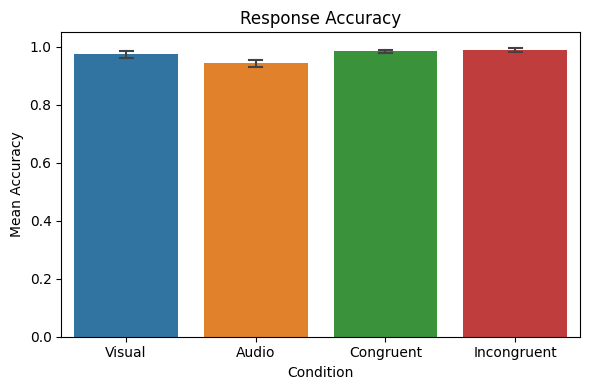

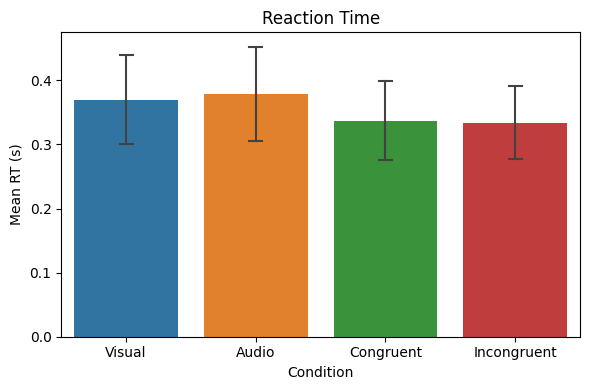

In [4]:
# plot

order = ['Visual', 'Audio', 'Congruent', 'Incongruent']

# Plot: response accuracy
plt.figure(figsize=(6,4))
sns.barplot(
    data=all_subjects_summary,
    x='cond',
    y='overall_acc',
    order=order,
    capsize=0.1,
    errwidth=1.5,
    ci=95
)
plt.ylim(0,1.05)
plt.ylabel('Mean Accuracy')
plt.xlabel('Condition')
plt.title('Response Accuracy')
plt.tight_layout()
plt.show()

# Plot: reaction time
plt.figure(figsize=(6,4))
sns.barplot(
    data=all_subjects_summary,
    x='cond',
    y='overall_rt',
    order=order,
    capsize=0.1,
    errwidth=1.5,
    ci='sd'
)
plt.ylabel('Mean RT (s)')
plt.xlabel('Condition')
plt.title('Reaction Time')
plt.tight_layout()
plt.show()

*significance test*

In [6]:
def run_permutation_test(
    data_df,
    analysis_col,
    group_cols=["roi", "cond"],
    conditions=None,
    rois=None,
    n_permutations=10000,
    seed=42,
    alpha=0.05,
    test_type="two_tailed",
    # correction_method="across_rois",
    plot_histograms=False,
    save_plots=False,
    plot_dir="permutation_plots"
):
    """
    Run permutation tests for any variable with flexible FDR correction options.
    Parameters:
    -----------
    data_df : pandas.DataFrame
        DataFrame with the data to analyze
    analysis_col : str
        Name of the column to analyze with permutation test
    group_cols : list
        List of columns to group by (e.g., ["roi", "cond"])
    conditions : list or None
        List of conditions to analyze. If None, all conditions are analyzed
    rois : list or None
        List of ROIs to analyze. If None, all ROIs are analyzed
    n_permutations : int
        Number of permutations to run
    seed : int
        Random seed for reproducibility
    alpha : float
        Significance level for FDR correction
    test_type : str
        Type of test to perform: "two_tailed", "greater", or "less"
    correction_method : str
        How to apply FDR correction:
        - "across_rois": Correct across ROIs within each condition (default)
        - "across_conditions": Correct across conditions within each ROI
        - "all_tests": Correct across all tests simultaneously
    plot_histograms : bool
        Whether to generate histogram plots
    save_plots : bool
        Whether to save plots to files
    plot_dir : str
        Directory to save plots (created if doesn't exist)
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with permutation test results including FDR-corrected p-values
    """
    # Validate parameters
    valid_test_types = ["two_tailed", "greater", "less"]
    if test_type not in valid_test_types:
        raise ValueError(f"test_type must be one of {valid_test_types}, got '{test_type}'")
    # valid_correction_methods = ["across_rois", "across_conditions", "all_tests"]
    # if correction_method not in valid_correction_methods:
    #     raise ValueError(f"correction_method must be one of {valid_correction_methods}, got '{correction_method}'")
    # Set random seed for reproducibility
    np.random.seed(seed)
    # Extract unique values for grouping variables if not provided
    if "roi" in group_cols and "roi" in data_df.columns:
        if rois is None:
            rois = data_df["roi"].unique()
    else:
        rois = [None]
    if "cond" in group_cols and "cond" in data_df.columns:
        if conditions is None:
            conditions = data_df["cond"].unique()
    else:
        conditions = [None]
    # Prepare results storage
    results = []
    plot_data = []  # Store data for plotting separately
    # Loop through ROIs and conditions
    for roi_idx, roi in enumerate(rois):
        if roi is not None:
            print(f"Processing ROI: {roi} ({roi_idx+1}/{len(rois)})")
        for cond in conditions:
            # Filter data
            filtered_data = data_df.copy()
            if roi is not None and "roi" in data_df.columns:
                filtered_data = filtered_data[filtered_data["roi"] == roi]
            if cond is not None and "cond" in data_df.columns:
                filtered_data = filtered_data[filtered_data["cond"] == cond]
            cond_data = filtered_data[analysis_col].values
            if len(cond_data) == 0:
                continue
            # Calculate observed mean
            observed_mean = np.mean(cond_data)
            # Perform permutation test against null hypothesis (mean = 0)
            # Generate all permuted means first
            permuted_means = []
            for _ in range(n_permutations):
                # Generate permutation by randomly flipping signs
                signs = np.random.choice([-1, 1], size=len(cond_data))
                permuted_data = cond_data * signs
                permuted_mean = np.mean(permuted_data)
                permuted_means.append(permuted_mean)
            permuted_means = np.array(permuted_means)
            # Apply appropriate test based on test_type using sum()
            if test_type == 'greater':
                p_value = np.sum(permuted_means >= observed_mean) / n_permutations
            elif test_type == 'less':
                p_value = np.sum(permuted_means <= observed_mean) / n_permutations
            elif test_type == 'two_tailed':
                p_value = np.sum(np.abs(permuted_means) >= np.abs(observed_mean)) / n_permutations
            # Store plot data if plotting is requested
            if plot_histograms:
                plot_data.append({
                    'permuted_means': permuted_means,
                    'observed_mean': observed_mean,
                    'p_value': p_value,
                    'roi': roi,
                    'cond': cond
                })
            # Store results
            results.append({
                "roi": roi,
                "cond": cond,
                "observed_mean": observed_mean,
                "std_error": np.std(cond_data, ddof=1) / np.sqrt(len(cond_data)),
                "n": len(cond_data),
                "p_value": p_value,
                "test_type": test_type,
                "significant": p_value < alpha
            })
    # Create plots if requested
    # if plot_histograms and plot_data:
    #     create_permutation_plots(plot_data, analysis_col, test_type, save_plots, plot_dir)
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    if len(results_df) == 0:
        return results_df
    # # Apply FDR correction based on specified method
    # results_df["p_value_fdr"] = np.nan
    # results_df["significant_fdr"] = False
    # results_df["n_corrections"] = 0
    # if correction_method == "across_rois" and "cond" in group_cols and "cond" in results_df.columns:
    #     # Apply FDR correction across ROIs within each condition
    #     for cond in results_df["cond"].unique():
    #         cond_mask = results_df["cond"] == cond
    #         cond_p_values = results_df[cond_mask]["p_value"].values
    #         if len(cond_p_values) > 0:
    #             rejected, p_corrected = fdrcorrection(cond_p_values, alpha=alpha, method='indep')
    #             results_df.loc[cond_mask, "p_value_fdr"] = p_corrected
    #             results_df.loc[cond_mask, "significant_fdr"] = rejected
    #             results_df.loc[cond_mask, "n_corrections"] = len(cond_p_values)
    # elif correction_method == "across_conditions" and "roi" in group_cols and "roi" in results_df.columns:
    #     # Apply FDR correction across conditions within each ROI
    #     for roi in results_df["roi"].unique():
    #         roi_mask = results_df["roi"] == roi
    #         roi_p_values = results_df[roi_mask]["p_value"].values
    #         if len(roi_p_values) > 0:
    #             rejected, p_corrected = fdrcorrection(roi_p_values, alpha=alpha, method='indep')
    #             results_df.loc[roi_mask, "p_value_fdr"] = p_corrected
    #             results_df.loc[roi_mask, "significant_fdr"] = rejected
    #             results_df.loc[roi_mask, "n_corrections"] = len(roi_p_values)
    # elif correction_method == "all_tests":
    #     # Apply FDR correction to all tests simultaneously
    #     all_p_values = results_df["p_value"].values
    #     if len(all_p_values) > 0:
    #         rejected, p_corrected = fdrcorrection(all_p_values, alpha=alpha, method='indep')
    #         results_df["p_value_fdr"] = p_corrected
    #         results_df["significant_fdr"] = rejected
    #         results_df["n_corrections"] = len(all_p_values)
    # else:
    #     # Fallback to all tests correction if specified method doesn't apply
    #     all_p_values = results_df["p_value"].values
    #     if len(all_p_values) > 0:
    #         rejected, p_corrected = fdrcorrection(all_p_values, alpha=alpha, method='indep')
    #         results_df["p_value_fdr"] = p_corrected
    #         results_df["significant_fdr"] = rejected
    #         results_df["n_corrections"] = len(all_p_values)
    # Sort and return
    sort_cols = [col for col in ["roi", "cond"] if col in results_df.columns] + ["p_value"]
    results_df = results_df.sort_values(by=sort_cols)
    return results_df

In [7]:

# Perform permutation test 

# Create a copy with values for testing
test_df = all_subjects_summary.copy()
test_df['accuracy_above_chance'] = test_df['overall_acc'] - 0.5 # Center accuracy around chance
test_df['rt'] = test_df['overall_rt']

# Run permutation tests for ACCURACY
print("="*70)
print("PERMUTATION TEST: ACCURACY (against chance = 0.5)")
print("="*70)

accuracy_results = run_permutation_test(
    data_df=test_df,
    analysis_col='accuracy_above_chance',
    group_cols=['cond'], 
    conditions=['Visual', 'Audio', 'Congruent', 'Incongruent'],
    rois=None,
    n_permutations=10000,
    seed=42,
    alpha=0.05,
    test_type='greater',  # One-tailed: accuracy > chance
    plot_histograms=False,
    save_plots=False,
    plot_dir=None
)

# Convert back to actual accuracy (add 0.5 back)
accuracy_results['mean_actual_accuracy'] = accuracy_results['observed_mean'] + 0.5
print("\nAccuracy Results (actual values):")
print(accuracy_results[['cond', 'mean_actual_accuracy', 'std_error', 'p_value']])

# Run permutation tests for REACTION TIME
print("\n" + "="*70)
print("PERMUTATION TEST: REACTION TIME (against 0)")
print("="*70)

rt_results = run_permutation_test(
    data_df=test_df,
    analysis_col='rt',
    group_cols=['cond'],
    conditions=['Visual', 'Audio', 'Congruent', 'Incongruent'],
    rois=None,
    n_permutations=10000,
    seed=42,
    alpha=0.05,
    test_type='greater', # One-tailed: rt > 0
    plot_histograms=False,
    save_plots=False,
    plot_dir=None
)

rt_results['mean_rt'] = rt_results['observed_mean']
print("\nReaction Time Results:")
print(rt_results[['cond', 'mean_rt', 'std_error', 'p_value']])

PERMUTATION TEST: ACCURACY (against chance = 0.5)

Accuracy Results (actual values):
          cond  mean_actual_accuracy  std_error  p_value
1        Audio              0.943704   0.006234      0.0
2    Congruent              0.984815   0.003472      0.0
3  Incongruent              0.988519   0.003472      0.0
0       Visual              0.975556   0.005966      0.0

PERMUTATION TEST: REACTION TIME (against 0)

Reaction Time Results:
          cond   mean_rt  std_error  p_value
1        Audio  0.378508   0.013459      0.0
2    Congruent  0.336791   0.011238      0.0
3  Incongruent  0.333661   0.010382      0.0
0       Visual  0.370019   0.012605      0.0
